<a href="https://colab.research.google.com/github/balkiss06/Predictive_maintenance/blob/main/predictive_maintenance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PREDICTIVE** **MAINTENANCE**
---



---



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import ConfusionMatrixDisplay


In [ ]:
d=pd.read_csv("/content/drive/MyDrive/formation/predictive_maintenance_dataset.csv")

print(d.head(4))

       date    device  failure    metric1  metric2  metric3  metric4  metric5  \
0  1/1/2015  S1F01085        0  215630672       55        0       52        6   
1  1/1/2015  S1F0166B        0   61370680        0        3        0        6   
2  1/1/2015  S1F01E6Y        0  173295968        0        0        0       12   
3  1/1/2015  S1F01JE0        0   79694024        0        0        0        6   

   metric6  metric7  metric8  metric9  
0   407438        0        0        7  
1   403174        0        0        0  
2   237394        0        0        0  
3   410186        0        0        0  


In [ ]:
print(d.columns)

Index(['date', 'device', 'failure', 'metric1', 'metric2', 'metric3', 'metric4',
       'metric5', 'metric6', 'metric7', 'metric8', 'metric9'],
      dtype='object')


In [ ]:
d.describe()

,failure,metric1,metric2,metric3,metric4,metric5,metric6,metric7,metric8,metric9
count,124494.000000,1.244940e+05,124494.000000,124494.000000,124494.000000,124494.000000,124494.000000,124494.000000,124494.000000,124494.000000
mean,0.000851,1.223881e+08,159.492706,9.940897,1.741120,14.222669,260172.657726,0.292528,0.292528,13.013848
std,0.029167,7.045933e+07,2179.677781,185.748131,22.908507,15.943028,99151.078547,7.436924,7.436924,275.661220
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,1.000000,8.000000,0.000000,0.000000,0.000000
25%,0.000000,6.128476e+07,0.000000,0.000000,0.000000,8.000000,221452.000000,0.000000,0.000000,0.000000
50%,0.000000,1.227974e+08,0.000000,0.000000,0.000000,10.000000,249799.500000,0.000000,0.000000,0.000000
75%,0.000000,1.833096e+08,0.000000,0.000000,0.000000,12.000000,310266.000000,0.000000,0.000000,0.000000
max,1.000000,2.441405e+08,64968.000000,24929.000000,1666.000000,98.000000,689161.000000,832.000000,832.000000,70000.000000


In [ ]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124494 entries, 0 to 124493
Data columns (total 12 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   date     124494 non-null  object
 1   device   124494 non-null  object
 2   failure  124494 non-null  int64 
 3   metric1  124494 non-null  int64 
 4   metric2  124494 non-null  int64 
 5   metric3  124494 non-null  int64 
 6   metric4  124494 non-null  int64 
 7   metric5  124494 non-null  int64 
 8   metric6  124494 non-null  int64 
 9   metric7  124494 non-null  int64 
 10  metric8  124494 non-null  int64 
 11  metric9  124494 non-null  int64 
dtypes: int64(10), object(2)
memory usage: 11.4+ MB


date       0
device     0
failure    0
metric1    0
metric2    0
metric3    0
metric4    0
metric5    0
metric6    0
metric7    0
metric8    0
metric9    0
dtype: int64


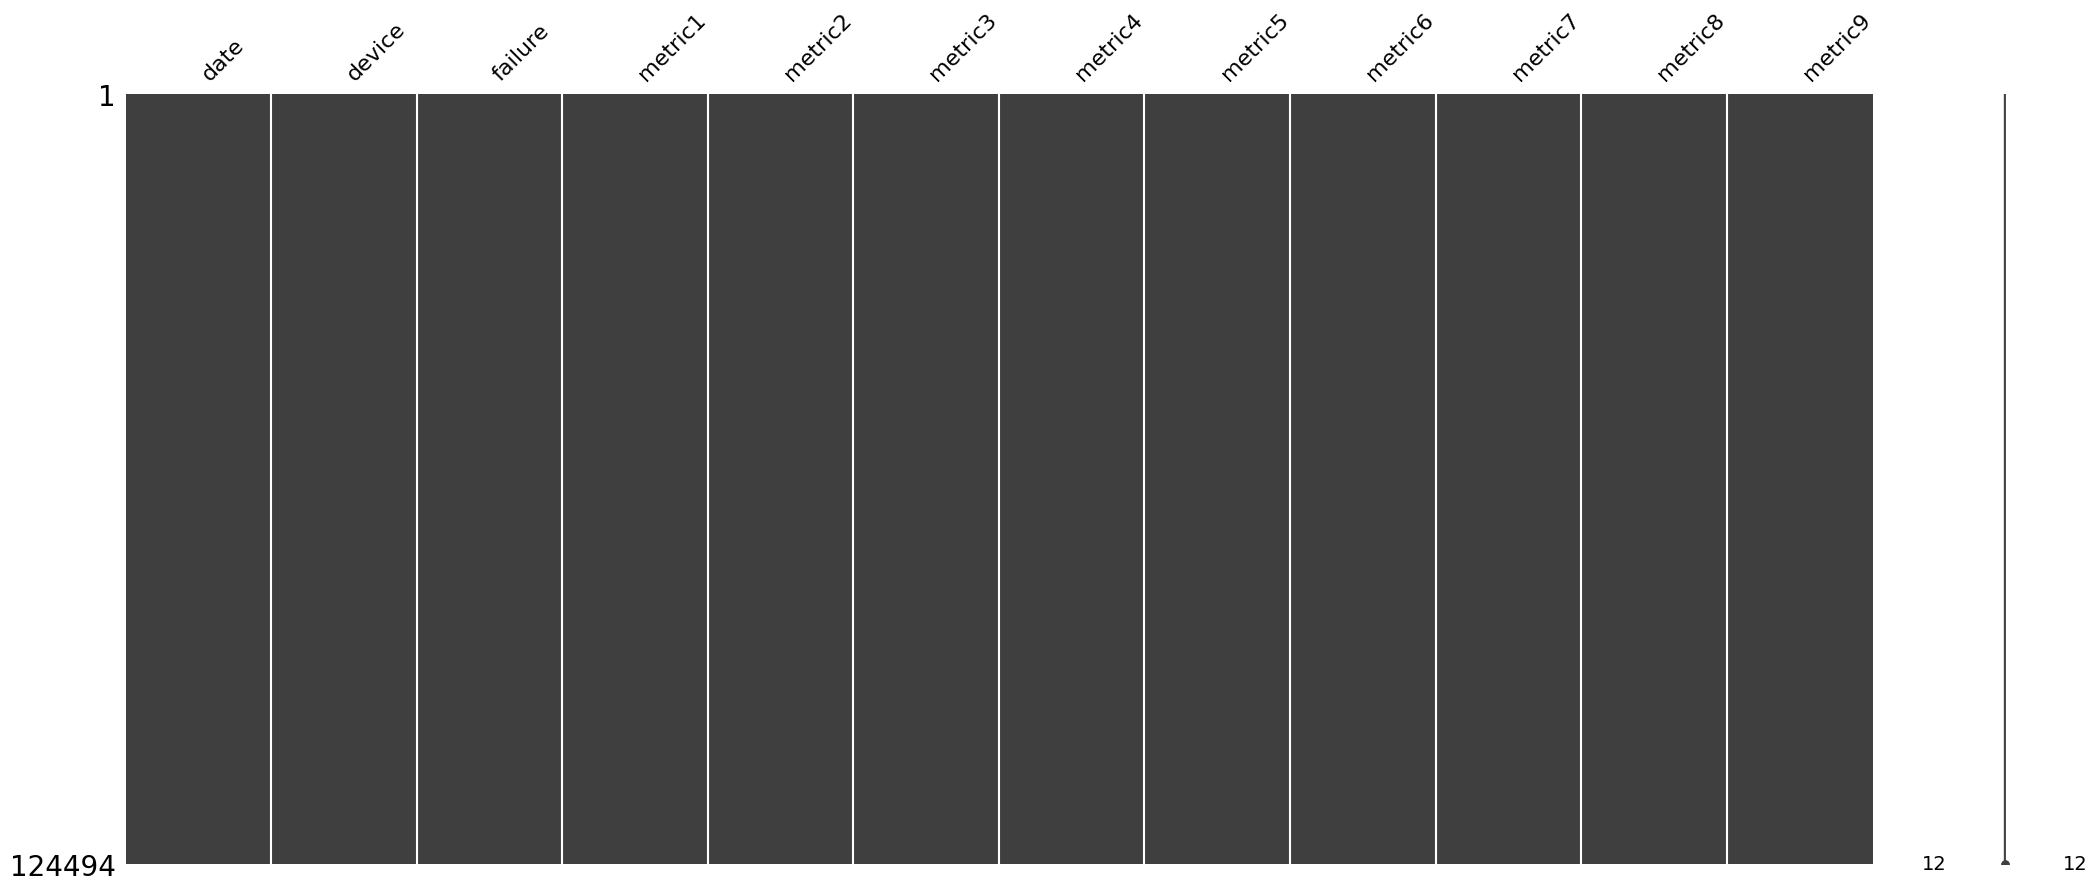

In [ ]:
print(d.isnull().sum())
msno.matrix(d)
plt.show()

In [ ]:
d["failure"].value_counts()

,count
failure,
0,124388
1,106


In [ ]:
print(d.duplicated().sum())

1


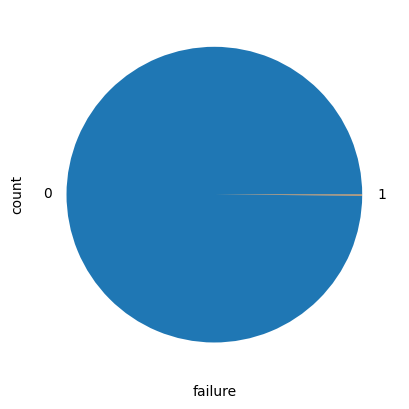

In [ ]:
d["failure"].value_counts().plot(kind="pie")
plt.xlabel("failure")
plt.show()

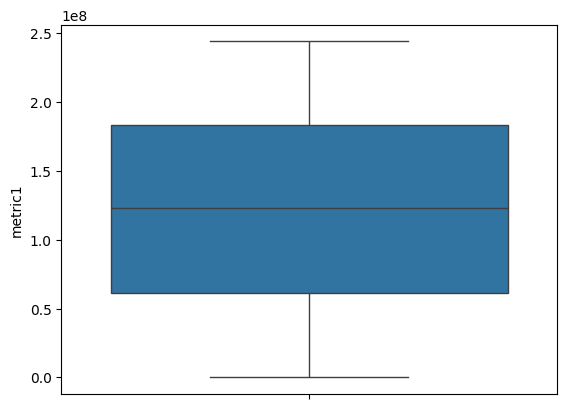

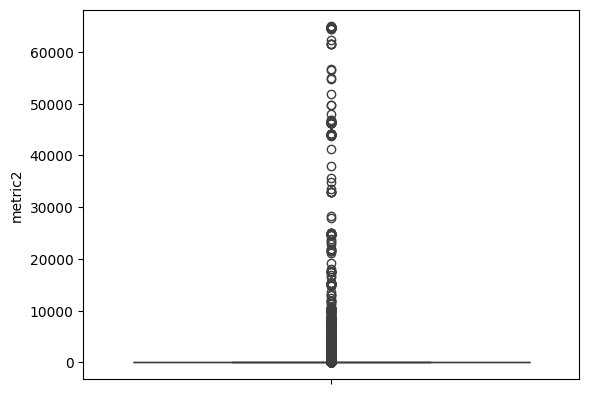

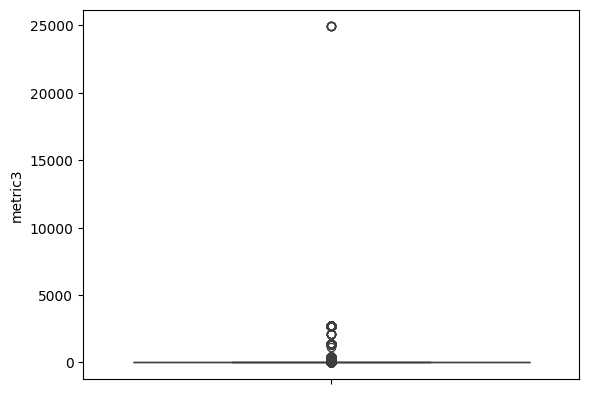

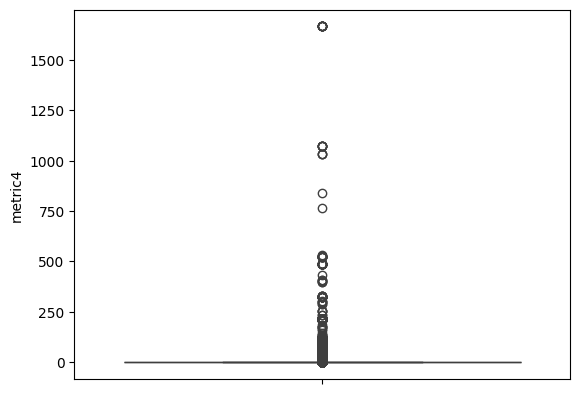

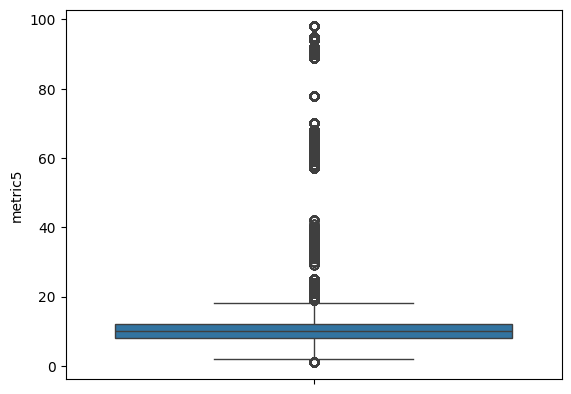

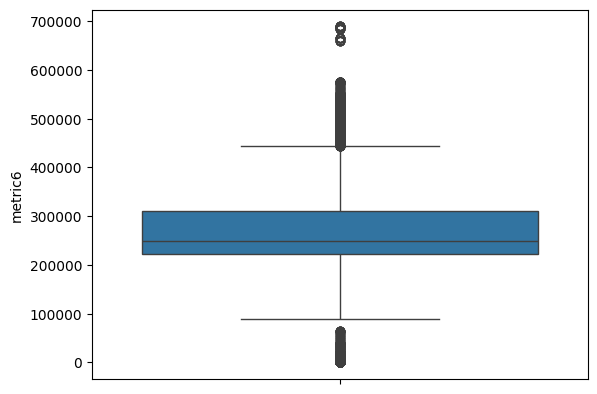

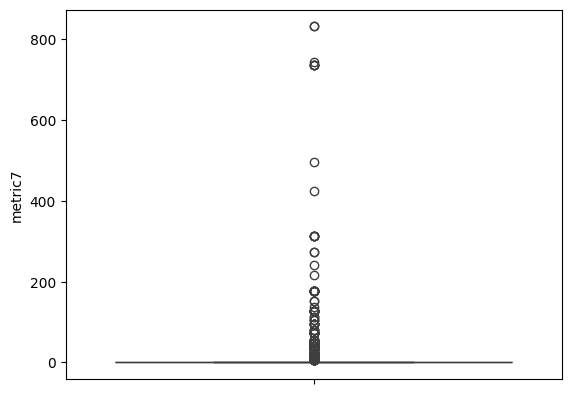

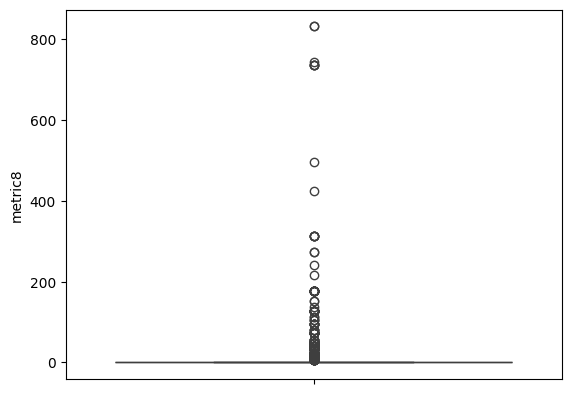

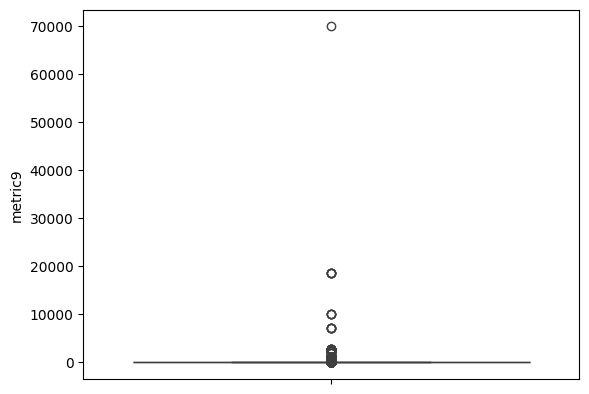

In [ ]:
sns.boxplot(d["metric1"])
plt.show()
sns.boxplot(d["metric2"])
plt.show()
sns.boxplot(d["metric3"])
plt.show()
sns.boxplot(d["metric4"])
plt.show()
sns.boxplot(d["metric5"])
plt.show()
sns.boxplot(d["metric6"])
plt.show()
sns.boxplot(d["metric7"])
plt.show()
sns.boxplot(d["metric8"])
plt.show()
sns.boxplot(d["metric9"])
plt.show()

          failure   metric1   metric2   metric3   metric4   metric5   metric6  \
failure  1.000000  0.001983  0.052901 -0.000948  0.067398  0.002270 -0.000550   
metric1  0.001983  1.000000 -0.004254  0.003701  0.001836 -0.003376 -0.001522   
metric2  0.052901 -0.004254  1.000000 -0.002617  0.146762 -0.013999 -0.026350   
metric3 -0.000948  0.003701 -0.002617  1.000000  0.097452 -0.006697  0.009031   
metric4  0.067398  0.001836  0.146762  0.097452  1.000000 -0.009773  0.024870   
metric5  0.002270 -0.003376 -0.013999 -0.006697 -0.009773  1.000000 -0.017049   
metric6 -0.000550 -0.001522 -0.026350  0.009031  0.024870 -0.017049  1.000000   
metric7  0.119055  0.000151  0.141366 -0.001884  0.045631 -0.009384 -0.012207   
metric8  0.119055  0.000151  0.141366 -0.001884  0.045631 -0.009384 -0.012207   
metric9  0.001067 -0.002256 -0.002049  0.369579  0.024892  0.003591  0.016566   

          metric7   metric8   metric9  
failure  0.119055  0.119055  0.001067  
metric1  0.000151  0.000151 

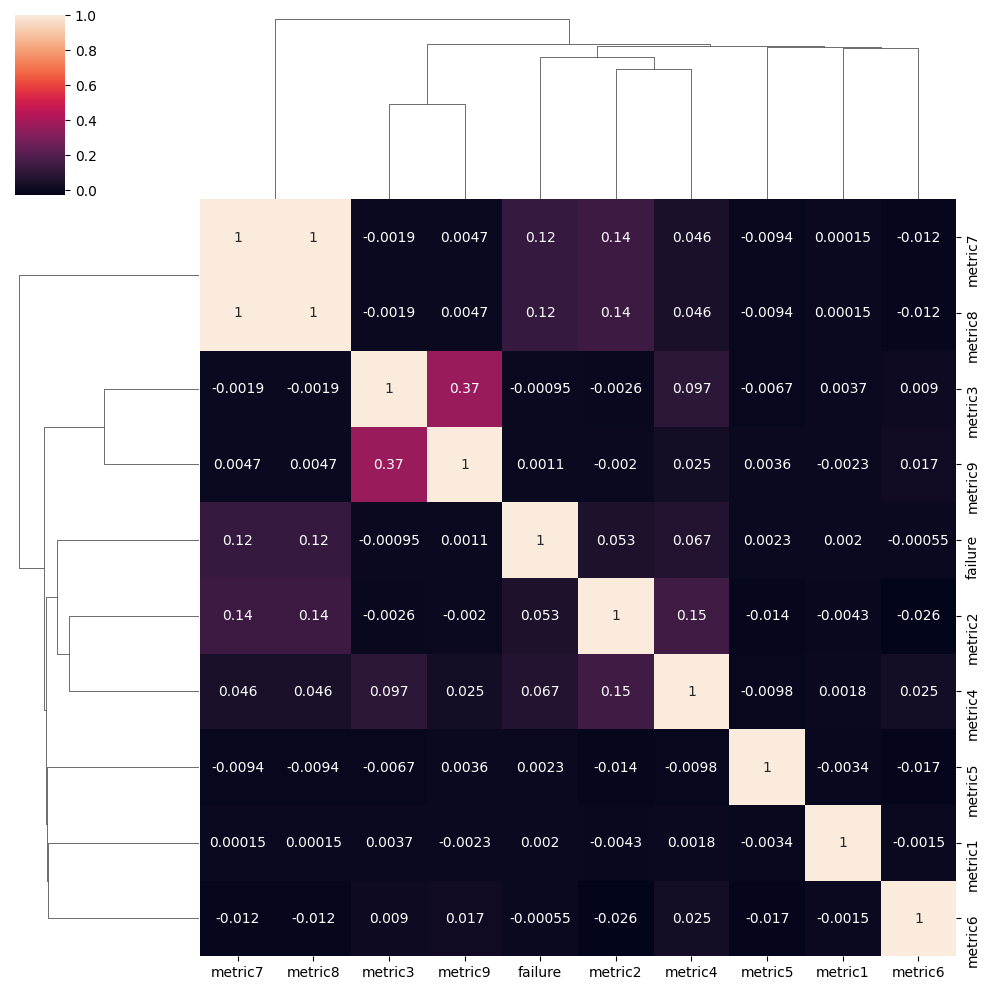

In [ ]:
print(d[["failure","metric1","metric2","metric3","metric4","metric5","metric6","metric7","metric8","metric9"]].corr())
sns.clustermap(d[["failure","metric1","metric2","metric3","metric4",
                  "metric5","metric6","metric7","metric8","metric9"]].corr(),annot = True)
plt.show()

In [ ]:
d["device"].value_counts()

,count
device,
S1F0E9EP,304
S1F0EGMT,304
Z1F0QL3N,304
W1F0SJJ2,304
Z1F0QLC1,304
...,...
S1F0A1PX,5
Z1F19VF5,5
S1F04KSC,4


In [ ]:
d["date"].value_counts()

,count
date,
1/1/2015,1163
1/2/2015,1163
1/3/2015,1163
1/4/2015,1162
1/5/2015,1161
...,...
10/30/2015,31
10/31/2015,31
10/29/2015,31


# ***PRETRAITEMENT***


---



In [ ]:
d= d.drop_duplicates()

In [ ]:
d["date"] = pd.to_datetime(d["date"])
d["year"] = d["date"].dt.year
d["month"] = d["date"].dt.month
d["day"] = d["date"].dt.day
print(d)

             date    device  failure    metric1  metric2  metric3  metric4  \
0      2015-01-01  S1F01085        0  215630672       55        0       52   
1      2015-01-01  S1F0166B        0   61370680        0        3        0   
2      2015-01-01  S1F01E6Y        0  173295968        0        0        0   
3      2015-01-01  S1F01JE0        0   79694024        0        0        0   
4      2015-01-01  S1F01R2B        0  135970480        0        0        0   
...           ...       ...      ...        ...      ...      ...      ...   
124489 2015-11-02  Z1F0MA1S        0   18310224        0        0        0   
124490 2015-11-02  Z1F0Q8RT        0  172556680       96      107        4   
124491 2015-11-02  Z1F0QK05        0   19029120     4832        0        0   
124492 2015-11-02  Z1F0QL3N        0  226953408        0        0        0   
124493 2015-11-02  Z1F0QLC1        0   17572840        0        0        0   

        metric5  metric6  metric7  metric8  metric9  year  mont

year
2015    124493
Name: count, dtype: int64


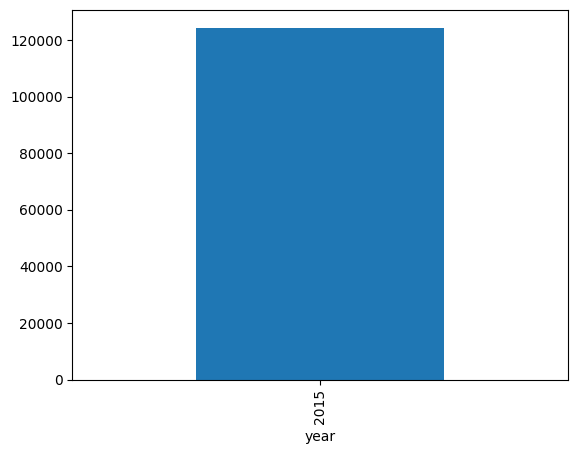

month
1     25032
3     19833
2     19500
4     12012
5     11330
7     10530
6     10469
8      8346
9      4470
10     2940
11       31
Name: count, dtype: int64


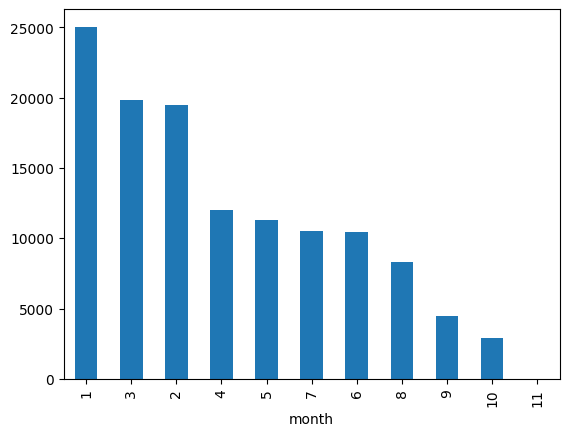

day
1     4742
2     4742
5     4706
4     4705
3     4677
6     4641
7     4345
8     4263
9     4263
10    4261
11    4261
12    4217
13    4154
14    4110
15    4076
16    4076
17    4033
18    3989
19    3981
20    3939
21    3894
22    3893
23    3850
24    3812
25    3806
26    3728
27    3726
28    3622
29    2948
30    2945
31    2088
Name: count, dtype: int64


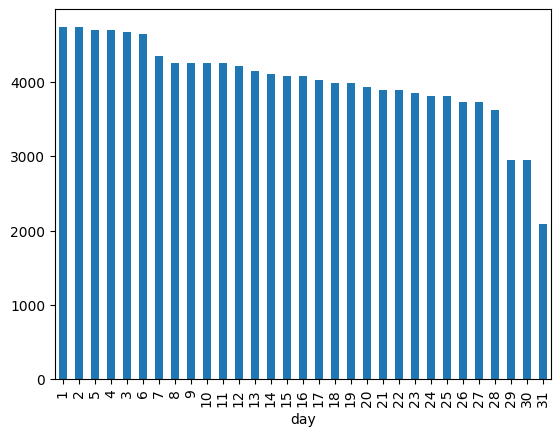

In [ ]:
print(d["year"].value_counts())
d["year"].value_counts().plot(kind="bar")
plt.show()

print(d["month"].value_counts())
d["month"].value_counts().plot(kind="bar")
plt.show()

print(d["day"].value_counts())
d["day"].value_counts().plot(kind="bar")
plt.show()

In [ ]:
e=LabelEncoder()
d["device_encoded"] = e.fit_transform(d["device"])

In [ ]:
d=d.drop(["device","date","metric8"],axis=1)
print(d)

        failure    metric1  metric2  metric3  metric4  metric5  metric6  \
0             0  215630672       55        0       52        6   407438   
1             0   61370680        0        3        0        6   403174   
2             0  173295968        0        0        0       12   237394   
3             0   79694024        0        0        0        6   410186   
4             0  135970480        0        0        0       15   313173   
...         ...        ...      ...      ...      ...      ...      ...   
124489        0   18310224        0        0        0       10   353705   
124490        0  172556680       96      107        4       11   332792   
124491        0   19029120     4832        0        0       11   350410   
124492        0  226953408        0        0        0       12   358980   
124493        0   17572840        0        0        0       10   351431   

        metric7  metric9  year  month  day  device_encoded  
0             0        7  2015      1 

# **SEPARARTION DES DONNEES**

---



In [ ]:
x = d.drop("failure",axis=1)
y = d["failure"]
print(x.shape, y.shape)

(124493, 12) (124493,)


In [ ]:
s=StandardScaler()
x=s.fit_transform(x)
print(x)

[[ 1.32336628 -0.04794011 -0.05351858 ... -1.17733042 -1.58618487
  -1.90228682]
 [-0.86599034 -0.0731732  -0.03736768 ... -1.17733042 -1.58618487
  -1.8961739 ]
 [ 0.72252504 -0.0731732  -0.05351858 ... -1.17733042 -1.58618487
  -1.89311744]
 ...
 [-1.46692888  2.14366828 -0.05351858 ...  2.71046228 -1.4720235
   1.3834077 ]
 [ 1.4840658  -0.0731732  -0.05351858 ...  2.71046228 -1.4720235
   1.40174646]
 [-1.48759733 -0.0731732  -0.05351858 ...  2.71046228 -1.4720235
   1.40480292]]


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(y_train.value_counts())
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)
sm=SMOTE()
x_train, y_train = sm.fit_resample(x_train, y_train)
print(y_train.value_counts())

failure
0    99504
1       90
Name: count, dtype: int64
(99594, 12) (99594,)
(24899, 12) (24899,)
failure
0    99504
1    99504
Name: count, dtype: int64


# **MODELE DU MACHINE LEARNING**

---



In [ ]:
!pip install xgboost
from xgboost import XGBClassifier
xg= XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=10,
    random_state=42,)

In [ ]:
xg.fit(x_train, y_train)
y_pred = xg.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

# **EVALUATION**

---



0.9991164303787301
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     24883
           1       0.20      0.12      0.15        16

    accuracy                           1.00     24899
   macro avg       0.60      0.56      0.58     24899
weighted avg       1.00      1.00      1.00     24899



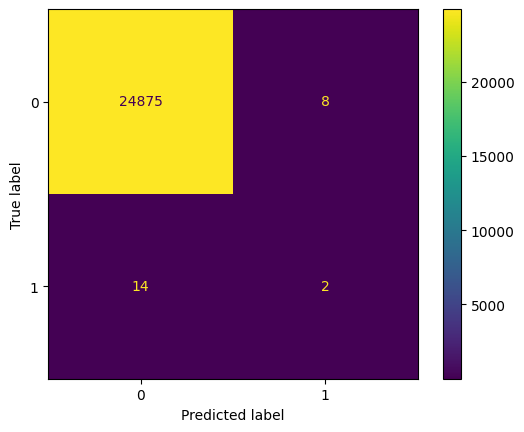

In [ ]:
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)
plt.show()

# **TEST**

---



In [ ]:
t=pd.DataFrame([{
    'metric1':100000,
    'metric2': 100,
    'metric3': 100,
    'metric4': 100,
    'metric5': 100,
    'metric6': 4000,
    'metric7': 100,
    'metric9': 100,
    'day': 5,
    'month': 12,
    'year': 2017,
    'device_encoded': 300,

    }])
print(t)
t=s.fit_transform(t)
prediction = xg.predict(t)
print(prediction)

   metric1  metric2  metric3  metric4  metric5  metric6  metric7  metric9  \
0   100000      100      100      100      100     4000      100      100   

   day  month  year  device_encoded  
0    5     12  2017             300  
[1]
